<center> <h1> Bitcoin Price Prediction </h1> </center>

## Introduction
Bitcoin is a type of digital currency that uses blockchain technology to enable peer-to-peer transactions without the need for a bank or government.
- **Technology:** Blockchain technology is decentralized digital ledger system that records transactions across many computers in a way that makes the data secure, transparent, and tamper-resistant.
- **Digital ledger:** is maintained and shared across the network
- **Block:** Each trasaction data like date/time of transfer,sender and reciever's cryptographic wallet address, amount being transferred etc are stored in a block
- **Chain:** Each block is linked to the previous block using cryptography, forming a continuous chain and hence the name blockchain.
- **Consensus Mechanisms:** Rules like Proof of Work or Proof of Stake ensure that all participants agree on the state of the ledger.
- **Immutability:** Once data is added to the blockchain, it cannot easily be altered or deleted, which prevents fraud and enhances trust.
- **Hash:** Each block has a unique digital fingerprint of the block’s data called hash

## Objective
- The objective of this project is to predict the 'bitcoin market price' of a particular day, using the market information of the previous 3 days.
- Following are the features available for predicting the market price

| S.No | Column Name                                      | Description                                                                 |
|------|--------------------------------------------------|-----------------------------------------------------------------------------|
| 1    | Date                                             | Date of observation (daily data).                                           |
| 2    | btc_market_price(response variable)              | The average USD market price across major Bitcoin exchanges.                |
| 3    | btc_total_bitcoins                               | Total number of Bitcoins mined and currently in circulation.                |
| 4    | btc_market_cap                                   | Market capitalization (total bitcoins in circulation × market price in USD).|
| 5    | btc_trade_volume                                 | USD exchange trade volume (estimated volume of trades on exchanges).        |
| 6    | btc_blocks_size                                  | Total block size (in MB) of all blocks mined per day.                       |
| 7    | btc_avg_block_size                               | Average size (in MB) of individual blocks mined.                            |
| 8    | btc_n_orphaned_blocks                            | Number of orphaned blocks (blocks not included in the main chain).          |
| 9    | btc_n_transactions_per_block                     | Average number of confirmed transactions per block.                         |
| 10   | btc_median_confirmation_time                     | Median time (in minutes) for a transaction to be confirmed.                 |
| 11   | btc_hash_rate                                    | Estimated number of terahashes per second the Bitcoin network is performing.|
| 12   | btc_difficulty                                   | Mining difficulty (relative to the easiest it can ever be).                  |
| 13   | btc_miners_revenue                               | Total revenue of miners per day (block rewards + transaction fees, in USD). |
| 14   | btc_transaction_fees                             | Total transaction fees paid to miners (in BTC).                             |
| 15   | btc_cost_per_transaction_percent                 | Miner revenue as a percentage of transaction volume.                        |
| 16   | btc_cost_per_transaction                         | Average miner revenue (USD) per transaction.                                |
| 17   | btc_n_unique_addresses                           | Number of unique Bitcoin addresses used per day.                            |
| 18   | btc_n_transactions                               | Total number of confirmed transactions per day.                             |
| 19   | btc_n_transactions_total                         | Cumulative total of confirmed transactions since Bitcoin’s creation.        |
| 20   | btc_n_transactions_excluding_popular             | Confirmed transactions per day excluding the top 100 most popular addresses.|
| 21   | btc_n_transactions_excluding_chains_longer_than_100 | Transactions per day excluding very long chain transactions (>100).       |
| 22   | btc_output_volume                                | Total value of all transaction outputs per day (in BTC).                    |
| 23   | btc_estimated_transaction_volume                 | Estimated transaction volume per day (excluding change outputs, in BTC).    |
| 24   | btc_estimated_transaction_volume_usd             | Estimated transaction volume per day in USD (excluding change outputs).     |

- The features "btc_n_transactions_**excluding_popular**" and "btc_n_transactions_**excluding_chains**_longer_than_100" are specialized Blockchain metrics to filter spam or non-standard transactions.
- To predict the bitcoin market price we need to **determine which of the above predictors are relevant**

## Details of the data

In [2]:
import pandas as pd
bitcoin_csv = pd.read_csv("bitcoin.csv")
bitcoin_df = pd.DataFrame(data = bitcoin_csv)
print("Number of observations in the data file:",bitcoin_df.shape[0])
print("Number of features in the data file:",bitcoin_df.shape[1]-1)
print("Response/target variable to be predicted:","'btc_market_price'")
#bitcoin_df.columns.has_duplicates
print("There are no duplicate records")
print("\n")
bitcoin_df.info()

Number of observations in the data file: 2920
Number of features in the data file: 23
Response/target variable to be predicted: 'btc_market_price'
There are no duplicate records


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2920 entries, 0 to 2919
Data columns (total 24 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Date                                                 2920 non-null   object 
 1   btc_market_price                                     2920 non-null   float64
 2   btc_total_bitcoins                                   2920 non-null   float64
 3   btc_market_cap                                       2920 non-null   float64
 4   btc_trade_volume                                     2899 non-null   float64
 5   btc_blocks_size                                      2920 non-null   float64
 6   btc_avg_block_size                                  

## Missing values
- From the above we can see that expect 'btc_trade_volume'(index number 4 with 2899 not null observations), all other features does not have any missing values

## Data Cleaning
- Removing 175 obseravtions where "btc_market_price" is 0 (Log transformations or percentage changes may fail; Model predictions can be skewed when Bitcoin price=0)
- Removing 21 observations with Null value for "btc_trade_volume" 

In [3]:
print("Number of observations:")
# Filtering records with btc_market_price = 0
#----------------------------------------------
bitcoin_cleaned_df = bitcoin_df[bitcoin_df["btc_market_price"] > 0].copy()
print("After filtering 175 observations with btc_market_price 0:",bitcoin_cleaned_df.shape[0])

# Filtering records with missing values
#---------------------------------------
bitcoin_cleaned_df = bitcoin_cleaned_df.dropna()
print("After filtering 21 observations with null values:",bitcoin_cleaned_df.shape[0])


Number of observations:
After filtering 175 observations with btc_market_price 0: 2745
After filtering 21 observations with null values: 2724


 ## Data Analysis

In [4]:
print("Date range of the observations:",bitcoin_cleaned_df["Date"].min(),bitcoin_cleaned_df["Date"].max())
print("Bitcoin market price range of the observations:",bitcoin_cleaned_df["btc_market_price"].min(),bitcoin_cleaned_df["btc_market_price"].max())

Date range of the observations: 2010-08-17 00:00:00 2018-02-20 00:00:00
Bitcoin market price range of the observations: 0.0609 19498.6833333


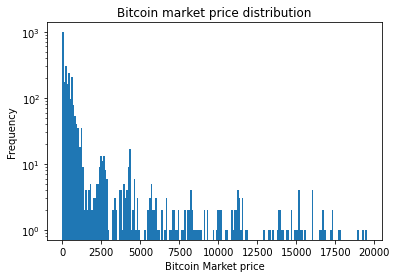

In [5]:
import matplotlib.pyplot as plt
#Frequency is log transformed for better clarity
plt.hist(bitcoin_cleaned_df["btc_market_price"],bins=200,log=True) 
plt.title("Bitcoin market price distribution")
plt.xlabel("Bitcoin Market price")
plt.ylabel("Frequency")
plt.show()

<AxesSubplot:>

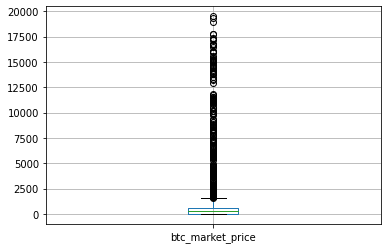

In [6]:
bitcoin_cleaned_df.boxplot("btc_market_price")

 ## Observations from the above plots (Bitcoin Price distribution and box plot) 
- From the above histogram and boxplot we can see that, the bitcoin market price is heavily right skewed and may have some outliers. 
- That is there are more data in the lower price range(btc_market_price < 2500) when comapred to the data available in higher price range (btc_market_price > 2500)

In [7]:
print("Number of observations with bitcoin market price less than or equal to 2500:",(bitcoin_cleaned_df["btc_market_price"] <= 2500).sum())
print("Number of observations with bitcoin market price above 2500:", (bitcoin_cleaned_df["btc_market_price"] > 2500).sum())


Number of observations with bitcoin market price less than or equal to 2500: 2479
Number of observations with bitcoin market price above 2500: 245


## Correlation Matrix and Heat map

In [8]:
bitcoin_cleaned_df["Date"] = pd.to_datetime(bitcoin_cleaned_df["Date"])
correlation_matrix = (bitcoin_cleaned_df.corr())

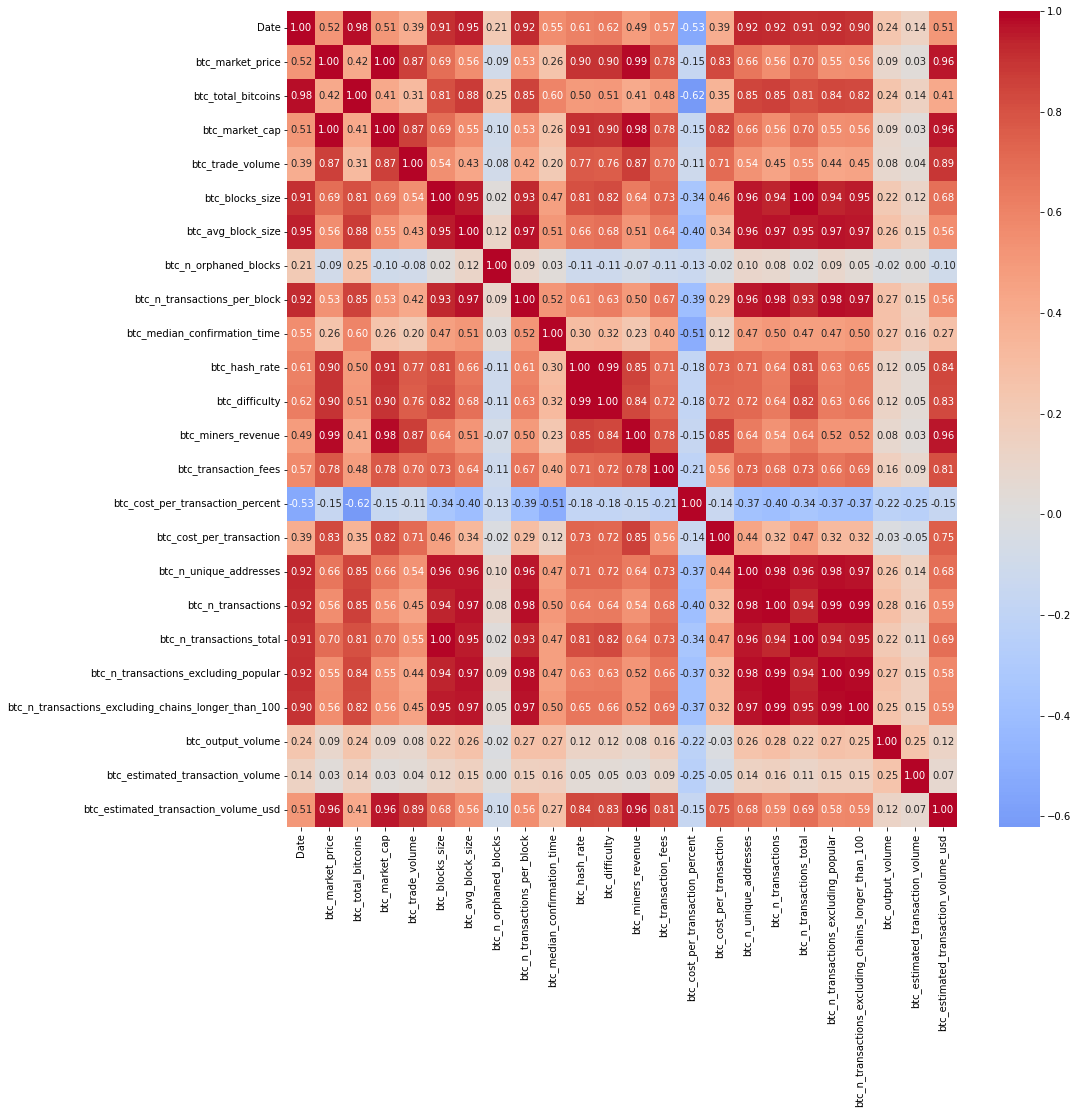

In [109]:
import seaborn as sns
plt.figure(figsize=(15,15))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

## Main Observations from the heat map(Correlation matrix)

==Multicollinaerity among predictors==
- "btc_block_size" and "btc_avg_block_size" - correlated with value 0.95
- "btc_hash_rate" and "btc_difficulty" -  correlated with value 0.99
- "btc_n_transactions" and "btc_n_transactions_excluding_chains_longer_than_100" -  correlated with value 0.99
- "btc_n_trasactions_excluding_popular" and "btc_n_transactions_excluding_chains_longer_than_100" -  correlated with value 0.99
- And there are several more collinear features.

## Features that are more than 80% collinear with 'btc_market_price'

In [9]:
print(correlation_matrix['btc_market_price'][correlation_matrix['btc_market_price']>0.80])

btc_market_price                        1.000000
btc_market_cap                          0.999806
btc_trade_volume                        0.865887
btc_hash_rate                           0.903281
btc_difficulty                          0.899732
btc_miners_revenue                      0.985298
btc_cost_per_transaction                0.832582
btc_estimated_transaction_volume_usd    0.959671
Name: btc_market_price, dtype: float64


== Predictor's correlation with the response variable btc_market_price ==
- "btc_market_price" and "btc_market_cap" are perfectly collinear with value 1.00. 
- "btc_market_price" and "btc_miners_revenue" are highly collinear with value 0.99
- "btc_market_price" and "btc_estimated_transaction_volume_usd" are highly collinear with value 0.96
- Other predictors like, btc_trade_volume,btc_hash_rate,btc_difficulty,btc_miners_revenue,btc_cost_per_transaction are highly positively correlated with bitcoin market price for a day.
- Hence these features can be a strong predictors in modeling the response varaible 'btc_market_price' 

## Creating lag fields that holds the information of the previous 3 days
- Goal is to predict the market price based on the information from past 3 days.
- We have 23 predictors(excluding the Date). For each of these predictors we are creating lag fields.
- Say we have a feature called feature_x. To predict today's market price we can lag features as follows 
1. feature_x_lag1 = yesterday's value of feaure_x 
2. feature_x_lag2 = day before yesterday's value of feaure_x
3. feature_x_lag3 = value of feaure_x 3 day's ago

## Creating lag variables for all features except Date,btc_market_cap
- The field 'btc_market_cap' is perfectly collinear with the response varaible 'btc_market_price' with correlation = 0.999806.
- Market Cap = Market Price x Total Bitcoins in Circulation
- This can cause data leakage and can lead to unrealistically high performance.
- Hence not inlcuding the field btc_market_cap as a lag variable.

In [10]:
# Number of lag days
num_of_lag_days = 3

lagged_features= {}
lagged_features = {'Date': bitcoin_cleaned_df['Date']}
                  
# Creating lag features
for lag in range(1, num_of_lag_days+1):
    for col in bitcoin_cleaned_df.columns:
        if (col != "Date" and col != "btc_market_cap"): 
            lagged_features[f"{col}_lag{lag}"] = bitcoin_cleaned_df[col].shift(lag)

lagged_features['btc_market_price'] = bitcoin_cleaned_df['btc_market_price']

bitcoin_lagged_df = pd.DataFrame(lagged_features)

# Dropping rows with NaN values created by lagging
bitcoin_lagged_df = bitcoin_lagged_df.dropna().copy()
bitcoin_lagged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2721 entries, 178 to 2919
Data columns (total 68 columns):
 #   Column                                                    Non-Null Count  Dtype         
---  ------                                                    --------------  -----         
 0   Date                                                      2721 non-null   datetime64[ns]
 1   btc_market_price_lag1                                     2721 non-null   float64       
 2   btc_total_bitcoins_lag1                                   2721 non-null   float64       
 3   btc_trade_volume_lag1                                     2721 non-null   float64       
 4   btc_blocks_size_lag1                                      2721 non-null   float64       
 5   btc_avg_block_size_lag1                                   2721 non-null   float64       
 6   btc_n_orphaned_blocks_lag1                                2721 non-null   float64       
 7   btc_n_transactions_per_block_lag1            

**From the above DataFrame information, we can confirm that on a particular day, there is market information about the previous three days.**

## Splitting the data into train and test
- 80% of the available data is split as training data and remaining 20% as test data in sequential order

In [11]:
train_size = int((len(bitcoin_lagged_df))*0.8)

#Excluding the target variable and storing the features in X_train and X_test
X_train = bitcoin_lagged_df.iloc[:train_size,0:len(bitcoin_lagged_df.columns)-1]
Y_train = bitcoin_lagged_df.iloc[:train_size]["btc_market_price"]
X_test = bitcoin_lagged_df.iloc[train_size:,0:len(bitcoin_lagged_df.columns)-1]
Y_test = bitcoin_lagged_df.iloc[train_size:]["btc_market_price"]

print("Dimension of X_train:", X_train.shape)
print("Dimension of Y_train:",Y_train.shape)
print("Dimension of X_test:",X_test.shape)
print("Dimension of Y_test:",Y_test.shape)


Dimension of X_train: (2176, 67)
Dimension of Y_train: (2176,)
Dimension of X_test: (545, 67)
Dimension of Y_test: (545,)


## Model Selection and prediction
**FULL MODEL**

In [12]:
from statsmodels.api import OLS, add_constant
from sklearn.metrics import mean_squared_error
import numpy as np

# Fitting full model 
# Excluding the Date column from predictors - since Date is not a numeric predictor of price
X_train_OLS = X_train.iloc[:,1:]
X_test_OLS = X_test.iloc[:,1:]

X_train_OLS_const = add_constant(X_train_OLS)
X_test_OLS_const = add_constant(X_test_OLS)

OLS_full_model = OLS(Y_train, X_train_OLS_const).fit()
print(OLS_full_model.summary())

                            OLS Regression Results                            
Dep. Variable:       btc_market_price   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     8593.
Date:                Thu, 09 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:45:32   Log-Likelihood:                -8921.2
No. Observations:                2176   AIC:                         1.798e+04
Df Residuals:                    2109   BIC:                         1.836e+04
Df Model:                          66                                         
Covariance Type:            nonrobust                                         
                                                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------

From the above **summary of the Full model** we can see that 
- Though Adj R-squared = 0.996
- Only few predictors have p_value less than the critical value 0.05
- **A large condition number indicates small changes in the data can cause very large changes in the prediction of unseen data.**
- **It also suggestes that predictors are highly correlated**

**Following are the predictors from the full model whose p_value < 0.05**

In [13]:
summary_table = OLS_full_model.summary2().tables[1] 
print(summary_table[summary_table['P>|t|'] < 0.05][["t","P>|t|"]])

                                                   t          P>|t|
btc_market_price_lag1                      42.468955  2.456311e-285
btc_estimated_transaction_volume_usd_lag1   3.493646   4.862957e-04
btc_market_price_lag2                      -6.390266   2.032027e-10
btc_trade_volume_lag2                      -2.045560   4.092347e-02
btc_n_transactions_per_block_lag2           2.189652   2.865873e-02
btc_miners_revenue_lag2                    -3.833888   1.298307e-04
btc_cost_per_transaction_lag2               2.584525   9.817949e-03
btc_market_price_lag3                       2.353654   1.868122e-02
btc_trade_volume_lag3                       6.115534   1.143593e-09
btc_avg_block_size_lag3                     2.605233   9.245727e-03
btc_miners_revenue_lag3                     3.593861   3.332864e-04


- Above predictor's p_value, indicate that these predictors can contribute significantly in predicting the market price
- We can see that **'btc_market_price_lag1'**, the market price of previous day is having the lowest p_value and is the most significant predictor in the full model with large t-stat. 
- **Though the above model performs well on training data, the model is more influenced by the previous day price - "btc_market_price_lag1"**
- And has a large condition number making the model unstable for unseen data

## Prediction and RMSE of FULL Model

In [14]:
from sklearn.metrics import r2_score
y_train_full_model_pred = OLS_full_model.predict(X_train_OLS_const)
y_test_full_model_pred = OLS_full_model.predict(X_test_OLS_const)

full_model_train_RMSE = np.sqrt(mean_squared_error(Y_train,y_train_full_model_pred))
full_model_test_RMSE = np.sqrt(mean_squared_error(Y_test,y_test_full_model_pred))

print("Full model TRAIN RMSE of full model:",full_model_train_RMSE)
print("Full model TEST RMSE of full model:",full_model_test_RMSE)

r2_test = r2_score(Y_test, y_test_full_model_pred)
print("R^2 on Full model test data:", r2_test)

Full model TRAIN RMSE of full model: 14.597874645204122
Full model TEST RMSE of full model: 397.6492798354393
R^2 on Full model test data: 0.9918385408130275


## Observations from the result of FULL model
- The full regression model **fits the training data well** with RMSE ~14.5 and R^2 = 0.996
- The full model maintains **predictive performance** on test data as well with RMSE ~398 and Test R^2 ~ 0.992
- Though this model is having good R^2 and RMSE, the p_value of most of the predictors are > 0.05
- Hence this full model is not reliable for unseen data.
- This model has high condition number indicating **high multicollinearity**.
- Since all the features are used, the model is also **not interpretable** 

## Variance Inflation factor
**Lagged features for which VIF less than 5**

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_df = pd.DataFrame()
vif_df["features"] = X_train.drop(columns=['Date']).columns
vif_df["VIF"]= [variance_inflation_factor(X_train.iloc[:,1:].values, i) for i in range(X_train.shape[1]-1)]

low_vif_features = vif_df[vif_df["VIF"] < 5 ]
low_vif_features

,features,VIF
2,btc_trade_volume_lag1,4.019360
5,btc_n_orphaned_blocks_lag1,1.636546
11,btc_transaction_fees_lag1,2.394196
12,btc_cost_per_transaction_percent_lag1,4.331987
19,btc_output_volume_lag1,2.561738
20,btc_estimated_transaction_volume_lag1,3.441097
24,btc_trade_volume_lag2,4.896471
27,btc_n_orphaned_blocks_lag2,1.648554
33,btc_transaction_fees_lag2,2.520944
34,btc_cost_per_transaction_percent_lag2,4.661257


## Lagged feature's correlation matrix
**Lagged features that are more than 80% collinear with 'btc_market_price'**

In [16]:
corr_mat_lagged_features = (bitcoin_lagged_df.corr())
high_corr_features = corr_mat_lagged_features.loc[corr_mat_lagged_features['btc_market_price'] > 0.80,['btc_market_price']]
high_corr_features= high_corr_features.drop(index='btc_market_price').copy()
high_corr_features


,btc_market_price
btc_market_price_lag1,0.997524
btc_trade_volume_lag1,0.865587
btc_hash_rate_lag1,0.902890
btc_difficulty_lag1,0.898796
btc_miners_revenue_lag1,0.982499
btc_cost_per_transaction_lag1,0.827673
btc_estimated_transaction_volume_usd_lag1,0.958440
btc_market_price_lag2,0.994669
btc_trade_volume_lag2,0.860679
btc_hash_rate_lag2,0.902349


## Custome OLS Model 
**With features for which VIF < 5 and with features that are more than 80% collinear with btc_market_price**

In [15]:
# Excluding the Date column from predictors - since Date is not a numeric predictor of price
selected_features = list(set(low_vif_features['features']) | set(high_corr_features.index))
X_train_VIF_OLS = X_train[selected_features]
X_test_VIF_OLS = X_test[selected_features]

X_train_VIF_OLS_const = add_constant(X_train_VIF_OLS)
X_test_VIF_OLS_const = add_constant(X_test_VIF_OLS)

OLS_VIF_model = OLS(Y_train, X_train_VIF_OLS_const).fit()
print("Summary of the custom model(Has features with VIF<5 and features with collinearity > 80% with response-btc_market_price)")
print(OLS_VIF_model.summary())

Summary of the custom model(Has features with VIF<5 and features with collinearity > 80% with response-btc_market_price)
                            OLS Regression Results                            
Dep. Variable:       btc_market_price   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 1.592e+04
Date:                Thu, 09 Oct 2025   Prob (F-statistic):               0.00
Time:                        19:28:15   Log-Likelihood:                -8955.9
No. Observations:                2176   AIC:                         1.798e+04
Df Residuals:                    2140   BIC:                         1.819e+04
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|    

## Observations from the results  of Custom Model
- Though the Adj.R^2 is good, still most of the predictors have p_value > 0.05.
- Indicating that most of the predictors are not significant
- And the model is not reliable for unseen data.
- The condition number is also high indicating multicollinearity

## Lasso Regression
- From the aforementioned heat map of the correlation matrix, we can see that multiple predictors are correlated with each other.
- Very high value of condition number of the FULL model also indicates very high multi collinearity.
- Hence Lasso regression would be helpful in shrinking the highly correlated predictor's coefficients to 0, by applying the regularization/penalty term

## Feature standardization
- Standardizing all numeric features(except Date)

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Computing the mean and standard deviation of each column in X_train and applying the same standardization to train and test predictors.
# Except Date(non numeric cannot be standardized) 
X_train_scaled = scaler.fit_transform(X_train.iloc[:,1:])
X_test_scaled = scaler.transform(X_test.iloc[:,1:])


# Converting back to DataFrame to have the column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.iloc[:,1:].columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.iloc[:,1:].columns)

X_test_scaled_df

print("Dimensions of scaled test and train data:")
print("Shape of X_train_scaled_df:", X_train_scaled_df.shape)
print("Shape of X_test_scaled_df:",X_test_scaled_df.shape)
print("Shape of Y_train:",Y_train.shape)
print("Shape of Y_test:",Y_test.shape)


Dimensions of scaled test and train data:
Shape of X_train_scaled_df: (2176, 66)
Shape of X_test_scaled_df: (545, 66)
Shape of Y_train: (2176,)
Shape of Y_test: (545,)


## Fitting Lasso model

In [20]:
from sklearn.linear_model import LassoCV
lasso = LassoCV(alphas=np.logspace(-1, 1, 100), cv=10, max_iter=10000)
lasso.fit(X_train_scaled_df, Y_train)

print("Best lambda (Lasso):", lasso.alpha_)
print("Minmum and Maximum Lambda:",lasso.alphas_.min(),lasso.alphas_.max())
print("\n")

# LASSO Train and TEST MSE
mprice_train_preds_lasso = lasso.predict(X_train_scaled_df)
mprice_test_preds_lasso = lasso.predict(X_test_scaled_df)

print("LASSO Train MSE:", mean_squared_error(Y_train, mprice_train_preds_lasso))
print("LASSO Test MSE:",mean_squared_error(Y_test, mprice_test_preds_lasso))
print("\n")

# LASSO RMSE 
print("LASSO Train RMSE:", np.sqrt(mean_squared_error(Y_train, mprice_train_preds_lasso)))
print("LASSO Test RMSE:",np.sqrt(mean_squared_error(Y_test, mprice_test_preds_lasso)))
print("\n")

print("LASSO R^2 on train:", lasso.score(X_train_scaled_df, Y_train))
print("LASSO R^2 on test :", lasso.score(X_test_scaled_df, Y_test))
print("\n")

# Lasso model fitting            
Selected_Predictors = X_train_scaled_df.columns[lasso.coef_ != 0]

X_train_lasso_OLS = X_train.loc[:,Selected_Predictors]
X_train_lasso_OLS_const = add_constant(X_train_lasso_OLS)
OLS_lasso_model = OLS(Y_train, X_train_lasso_OLS_const).fit()
print("Summary of Lasso Model:")
print(OLS_lasso_model.summary())




Best lambda (Lasso): 0.24201282647943823
Minmum and Maximum Lambda: 0.1 10.0


LASSO Train MSE: 230.75490423945956
LASSO Test MSE: 154147.6058345032


LASSO Train RMSE: 15.190618955113697
LASSO Test RMSE: 392.61635961139365


LASSO R^2 on train: 0.9959879772718491
LASSO R^2 on test : 0.9920438273925279


Summary of Lasso Model:
                            OLS Regression Results                            
Dep. Variable:       btc_market_price   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 3.601e+04
Date:                Thu, 09 Oct 2025   Prob (F-statistic):               0.00
Time:                        22:46:45   Log-Likelihood:                -8999.8
No. Observations:                2176   AIC:                         1.803e+04
Df Residuals:                    2160   BIC:                         1.812e+04
Df Model:                          15 

## Observation from Lasso results
- **Best Lambda ~ 0.24**. 
- Though the model explains ~99% of the variance in training and ~99% in test data, most of the predictors have high p_value.
- And **among the non-zero coefficients**, the previous day market price **(btc_market_price_lag1) pvalue is low(0) and very high t-stat(164.88), indicating that the previous day market price is strongly driving the prediction of the btc_market_price.**
- This indicates that, **the strongest predictor of today’s market price is yesterday’s market price.**
- When we do T-test or ANOVA F-test to test if the predictor 'btc_market_price_lag1' will be statistically significant, the t-stat and f-test is expected to be high, indicating the predictor is statistically significant and the null hypotesis would be rejected. (This is because, when the coefficient is high, Standard Error will be low, t-stat will be high and hence pvalue of the predictor will be low)
- **The above model yields good predictive performance but limits interpretability of other predictors(other than btc_market_price_lag1).**

## Actual vs Predicted values of bitcoin market price (Lasso regression)

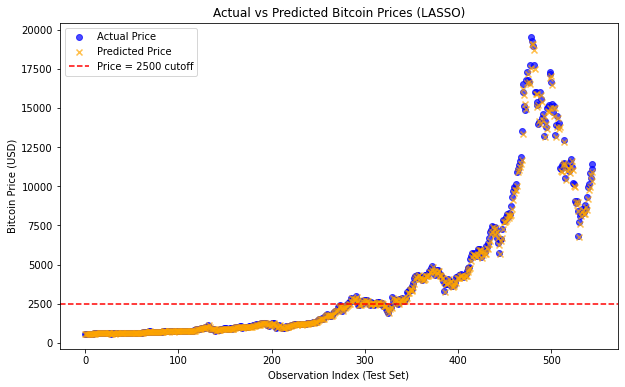

In [21]:
# Scatter plot of actual price vs absolute error
plt.figure(figsize=(10,6))

# Plot actual prices
plt.scatter(range(len(Y_test)), Y_test, 
            color="blue", marker="o", label="Actual Price", alpha=0.7)

# Plot predicted prices
plt.scatter(range(len(mprice_test_preds_lasso)), mprice_test_preds_lasso, 
            color="orange", marker="x", label="Predicted Price", alpha=0.7)

plt.axhline(y=2500, color="red", linestyle="--", label="Price = 2500 cutoff")

plt.xlabel("Observation Index (Test Set)")
plt.ylabel("Bitcoin Price (USD)")
plt.title("Actual vs Predicted Bitcoin Prices (LASSO)")
plt.legend()
plt.show()

- From the plot we can see that the actual and predicted bitcoin market price(of test data) are almost the same, for bitcoin price <= 2500
- For larger values of bitcoin price, the predcited price have some error. And hence in the results we see **~Test MSE: 154147.60 and TEST RMSE ~392.61**

## Mean Absolute Percentage Error(MAPE - Relative error)

In [22]:
results = pd.DataFrame({
    "actual": Y_test,
    "predicted": mprice_test_preds_lasso
})

# Define error metrics
results["abs_error"] = np.abs(results["actual"] - results["predicted"])
results["pct_error"] = results["abs_error"] / results["actual"] * 100

# Split the data into 2 groups
low_price = results[results["actual"] <= 2500]
high_price = results[results["actual"] > 2500]

# Computing MAPE for low price and high price groups
mape_low = low_price["pct_error"].mean()
mape_high = high_price["pct_error"].mean()

print(f"Overall MAPE: {results['pct_error'].mean():.2f}%")
print(f"Mean Absolute Percentage Error (btc_market_price ≤ 2500): {mape_low:.2f}%")
print(f"Mean Absolute Percentage Error (btc_market_price > 2500): {mape_high:.2f}%")

Overall MAPE: 3.43%
Mean Absolute Percentage Error (btc_market_price ≤ 2500): 2.51%
Mean Absolute Percentage Error (btc_market_price > 2500): 4.56%


- The percentage of error for lower range of bitcoin price is less compared to bitcoin price in higher range.
- This is evident from the below plot

## Fitted vs Residual Plot(LASSO regression)

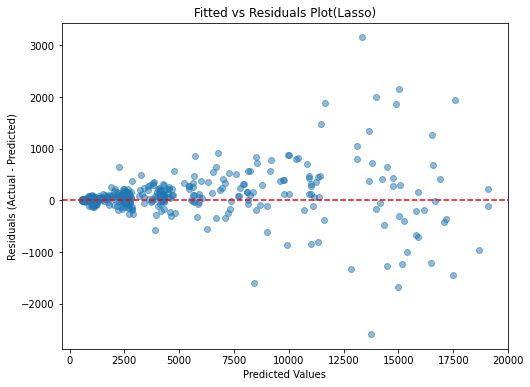

In [23]:
residuals = Y_test - mprice_test_preds_lasso
plt.figure(figsize=(8,6))
plt.scatter(mprice_test_preds_lasso, residuals, alpha=0.5)
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Fitted vs Residuals Plot(Lasso)")
plt.show()

- From the Fitted vs Residual plot for lasso regression, we can see that for lower range(< 2500 USD) of fitted values, the residuals are closer to zero
- As the bitcoin price increases (> 2500 USD) the residuals values are away from 0
- To check how ridge regression performs and also to include the lower order lag variables, we can try if ridge regression can give a better results
## Ridge Regression

In [24]:
from sklearn.linear_model import RidgeCV 
alphas = np.logspace(-1, 1, 100)
ridge = RidgeCV(alphas=alphas)
ridge.fit(X_train_scaled_df, Y_train)

print("Best lambda (Ridge):", ridge.alpha_)
print("Minmum and Maximum Lambda:",alphas.min(),alphas.max())
print("\n")

# Ridge Train and TEST MSE
mprice_train_preds_ridge = ridge.predict(X_train_scaled_df)
mprice_test_preds_ridge = ridge.predict(X_test_scaled_df)

print("Ridge Train MSE:", mean_squared_error(Y_train, mprice_train_preds_ridge))
print("Ridge Test MSE:",mean_squared_error(Y_test, mprice_test_preds_ridge))
print("\n")

# Ridge RMSE 
print("Ridge Train RMSE:", np.sqrt(mean_squared_error(Y_train, mprice_train_preds_ridge)))
print("Ridge Test RMSE:",np.sqrt(mean_squared_error(Y_test, mprice_test_preds_ridge)))
print("\n")

print("Ridge R^2 on train:", ridge.score(X_train_scaled_df, Y_train))
print("Ridge R^2 on test :", ridge.score(X_test_scaled_df, Y_test))
print("\n")

# Ridge coefficients
ridge_predictors_coef_df = pd.DataFrame({
            "Predictors":X_train_scaled_df.columns,
            "Coefficients": ridge.coef_
            })
print("Ridge Predictors and Coefficients:")
ridge_predictors_coef_df


Best lambda (Ridge): 0.16681005372000587
Minmum and Maximum Lambda: 0.1 10.0


Ridge Train MSE: 213.68085944247838
Ridge Test MSE: 153138.20197840885


Ridge Train RMSE: 14.617826768794272
Ridge Test RMSE: 391.32876456811715


Ridge R^2 on train: 0.9962848353430251
Ridge R^2 on test : 0.9920959267505832


Ridge Predictors and Coefficients:


,Predictors,Coefficients
0,btc_market_price_lag1,261.997325
1,btc_total_bitcoins_lag1,-1.514315
2,btc_trade_volume_lag1,-0.948902
3,btc_blocks_size_lag1,-26.337229
4,btc_avg_block_size_lag1,-1.842700
...,...,...
61,btc_n_transactions_excluding_popular_lag3,-4.464808
62,btc_n_transactions_excluding_chains_longer_tha...,-0.477741
63,btc_output_volume_lag3,-0.024359
64,btc_estimated_transaction_volume_lag3,0.008235


## Observations from Ridge regression results
- RidgeCV tested 100 lambda values between 0.1 and 10 (log-spaced).
- The best lambda was 0.1668, i.e. very close to the minimum tested.
- Train error is extremely small and the model fits training data well.
- Test error is much larger (Test RMSE 391  vs. Train RMSE 15) 
- Though test R^2 is very high, the absolute test RMSE (~391 USD) is very large.
- **Overall the Ridge model explains the variance in the response variable(with high R^2)**
- **But slightly low TRAIN MSE and high TEST MSE shows that the model is overfitting**

## Fitted vs Residual Plot(Ridge regression)

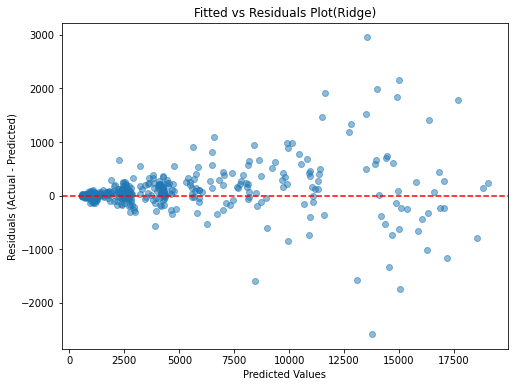

In [25]:
residuals = Y_test - mprice_test_preds_ridge
plt.figure(figsize=(8,6))
plt.scatter(mprice_test_preds_ridge, residuals, alpha=0.5)
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Fitted vs Residuals Plot(Ridge)")
plt.show()

- From the plot we can see that the residuals are scattered around 0, and there is no obvious pattern, hence **Linearity assumption is satisfied**
- But the plot clearly shows that **equal variance assumption is NOT SATISFIED** 
- That is for lower range(< 2500 USD) of fitted values, the residuals are closer to zero
- As the bitcoin price increases (> 2500 USD) the residual become high.

# LOG TRANSFORMATION OF RESPONSE VARIABLE(using Ridge regression)

In [228]:
Y_train_log = np.log(Y_train)
Y_test_log =  np.log(Y_test)
alphas = np.logspace(-1, 1, 100)
ridge_log = RidgeCV(alphas=alphas)
ridge_log.fit(X_train_scaled_df,Y_train_log)

print("Best lambda (Ridge):", ridge_log.alpha_)
print("Minmum and Maximum Lambda:",alphas.min(),alphas.max())
print("\n")

Y_train_preds_ridge_log = ridge_log.predict(X_train_scaled_df)
Y_test_preds_ridge_log = ridge_log.predict(X_test_scaled_df)

# Residual std on log scale
sigma2 = np.mean((Y_train_log - ridge_log.predict(X_train_scaled_df))**2)

# Back-transform with bias correction
Y_train_pred_original = np.exp(Y_train_preds_ridge_log + 0.5 * sigma2)
Y_test_pred_original  = np.exp(Y_test_preds_ridge_log  + 0.5 * sigma2)

# RMSE on original scale
rmse_train = np.sqrt(mean_squared_error(Y_train, Y_train_pred_original))
rmse_test  = np.sqrt(mean_squared_error(Y_test, Y_test_pred_original))

print("RMSE Train (original scale, corrected):", rmse_train)
print("RMSE Test (original scale, corrected):", rmse_test)
print("\n")

results = pd.DataFrame({
    "actual": Y_test,
    "predicted": Y_test_pred_original
})

# Define error metrics
results["abs_error"] = np.abs(results["actual"] - results["predicted"])
results["pct_error"] = results["abs_error"] / results["actual"] * 100

# Split the data into 2 groups
low_price = results[results["actual"] <= 2500]
high_price = results[results["actual"] > 2500]

# Computing MAPE for low price and high price groups
mape_low = low_price["pct_error"].mean()
mape_high = high_price["pct_error"].mean()

print(f"Overall MAPE: {results['pct_error'].mean():.2f}%")
print(f"Mean Absolute Percentage Error (btc_market_price ≤ 2500): {mape_low:.2f}%")
print(f"Mean Absolute Percentage Error (btc_market_price > 2500): {mape_high:.2f}%")


Best lambda (Ridge): 3.4304692863149193
Minmum and Maximum Lambda: 0.1 10.0


RMSE Train (original scale, corrected): 183.28118677828647
RMSE Test (original scale, corrected): 13663982695.475113


Overall MAPE: 13283514.65%
Mean Absolute Percentage Error (btc_market_price ≤ 2500): 419.43%
Mean Absolute Percentage Error (btc_market_price > 2500): 29548529.20%


- From the exploded value of TEST RMSE we can see that Response LOG TRANSFORMATION works when the response varaible are roughly of same magnitude.
- But in this dataset the Bitcoin price is heavily right skewed
- That is as seen in the analysis
1. Number of observations with bitcoin market price <= 2500 USD is 2479
2. Number of observations with bitcoin market price > 250 USD is 245
- Hence for this dataset the **original Ridge model on raw price worked better than ridge regression with log transformed response varaible**

## LOG transformed Bitcoin distribution

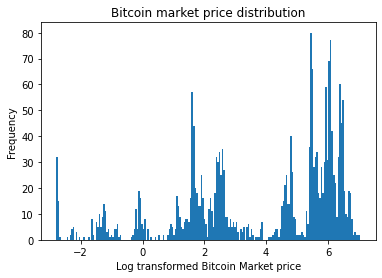

In [229]:
plt.hist(Y_train_log,bins=200) 
plt.title("Bitcoin market price distribution")
plt.xlabel("Log transformed Bitcoin Market price")
plt.ylabel("Frequency")
plt.show()

- From the above plot we can see that, **after log transformation of the response varaible, the right skew has slightly reduced but it is NOT close to normal distribution**
- Hence we see that bitcoin price has more time dependent volatile data
- Since the log normal assumption did not hold good here, the ridge regression with log transformed data did not work as expected.

## SPLINES (Piecewise polynomial)
- Splines allow model to be locally flexible without overfitting globally
- Splines are piecewise polynomial joined at specific points called knots
- Since Bitcoin price is highly nonlinear and volatile data modeling with splines may help
- Have used cubic splines (degree=3) with varying number of knots (2–5).
- Combined with RidgeCV regularization, to control overfitting.
- And Compared performance on train vs test data set.

In [203]:
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline


alphas = np.logspace(-1, 1, 100)

results=[]
for n_knots in range(2, 6):
    spline_ridge_model = make_pipeline(
        SplineTransformer(degree=3, n_knots=n_knots, include_bias=True),
        RidgeCV(alphas=alphas, cv=10)
    )
    spline_ridge_model.fit(X_train_scaled_df, Y_train)

    # Predictions
    Y_train_pred = spline_ridge_model.predict(X_train_scaled_df)
    Y_test_pred  = spline_ridge_model.predict(X_test_scaled_df)
    
    # Metrics
    train_mse = mean_squared_error(Y_train, Y_train_pred)
    test_mse  = mean_squared_error(Y_test, Y_test_pred)
    train_rmse = np.sqrt(train_mse)
    test_rmse  = np.sqrt(test_mse)
    train_r2 = spline_ridge_model.score(X_train_scaled_df, Y_train)
    test_r2  = spline_ridge_model.score(X_test_scaled_df, Y_test)
    best_alpha = spline_ridge_model.named_steps['ridgecv'].alpha_

    results.append({
        "n_knots": n_knots,
        "Best alpha": best_alpha,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R2": train_r2,
        "Test R2": test_r2
    })

results_df = pd.DataFrame(results)
results_df

,n_knots,Best alpha,Train RMSE,Test RMSE,Train R2,Test R2
0,2,0.100000,14.891717,5247.773891,0.996144,-0.421404
1,3,0.100000,14.010349,5267.578435,0.996587,-0.432153
2,4,0.210490,13.805875,5290.105887,0.996686,-0.444429
3,5,0.351119,13.930252,5274.709776,0.996626,-0.436033


## Observations from spline polynomial regression(with Ridge)
1. Train Fit
    - Train RMSE stays around 14 across all models.
    - Train R² ~ 0.996, meaning splines fit training data very well.
2. Test Performance
    - Test RMSE exploded to ~5200–5290 much worse than Ridge regression (which had ~391).
    - Test R² is negative, meaning the spline models perform worse, and the model is clearly overfitting the training data
3. Number of knots (2–5)
    - Increasing n_knots did not improve Test error and Test R^2.
    
**Spline polynomial regression with 2–5 knots fit the training data well but performed very poorly on test data, indicating severe overfitting.**
**Ridge regression without splines was more effective for Bitcoin price prediction.**

## Principal Component Analysis(PCA)
- Many of the predictors are highly collinear.
- PCA can transform correlated predictors into orthogonal (uncorrelated) principal components.
- Each component is a linear combination of the original predictors.
- We can use these components as predictors in regression, avoiding multicollinearity.

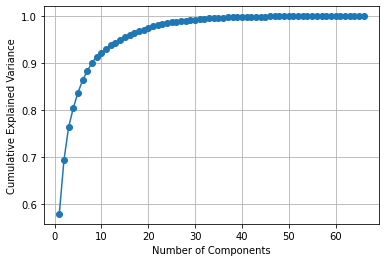

In [230]:
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X_train_scaled_df)

# Variance explained by each component
explained_variance = pca.explained_variance_ratio_

# Cumulative variance
cumulative_variance = explained_variance.cumsum()

plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()


In [ ]:
# Fit PCA with top 15 components
pca = PCA(n_components=15)  
X_train_pca = pca.fit_transform(X_train_scaled_df)
X_test_pca = pca.transform(X_test_scaled_df)

#Adding constant term for intercept
X_train_pca_const = add_constant(X_train_pca)
X_test_pca_const = add_constant(X_test_pca)

# Fitting OLS using statsmodels
pca_model = OLS(Y_train, X_train_pca_const).fit()

print("Summary of OLS model fit using PCA components:")
print(pca_model.summary())

Summary of OLS model fit using PCA components:
                            OLS Regression Results                            
Dep. Variable:       btc_market_price   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     6791.
Date:                Mon, 29 Sep 2025   Prob (F-statistic):               0.00
Time:                        17:19:17   Log-Likelihood:                -10796.
No. Observations:                2176   AIC:                         2.162e+04
Df Residuals:                    2160   BIC:                         2.172e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

In [231]:
# PCA Train and TEST MSE
Y_train_preds_pca = pca_model.predict(X_train_pca_const)
Y_test_preds_pca = pca_model.predict(X_test_pca_const)


print("PCA Train MSE:", mean_squared_error(Y_train, Y_train_preds_pca))
print("PCA Test MSE:",mean_squared_error(Y_test, Y_test_preds_pca))
print("\n")

# PCA Train and Test RMSE 
print("PCA Train RMSE:", np.sqrt(mean_squared_error(Y_train, Y_train_preds_pca)))
print("PCA Test RMSE:",np.sqrt(mean_squared_error(Y_test, Y_test_preds_pca)))
print("\n")

# PCA Train and Test R^2
print("PCA R^2 on train:", r2_score(Y_train,Y_train_preds_pca))
print("PCA R^2 on test :", r2_score(Y_test,Y_test_preds_pca))
print("\n")


PCA Train MSE: 1194.222678105128
PCA Test MSE: 3973566.5718686534


PCA Train RMSE: 34.55752708318591
PCA Test RMSE: 1993.380689148125


PCA R^2 on train: 0.9792366340259485
PCA R^2 on test : 0.7949083844545077




## Fitted vs Residual Plot(PCA regression)

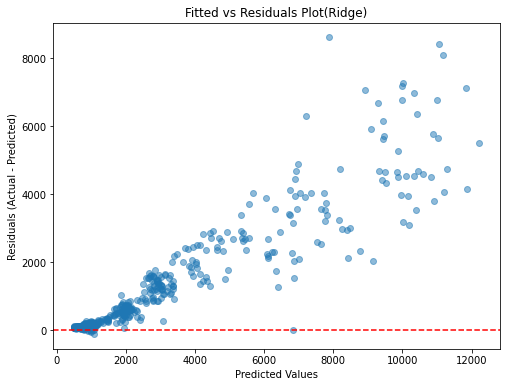

In [232]:
residuals = Y_test - Y_test_preds_pca
plt.figure(figsize=(8,6))
plt.scatter(Y_test_preds_pca, residuals, alpha=0.5)
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Fitted vs Residuals Plot(Ridge)")
plt.show()

## Observations from the PCA model
- Train R² = 0.979
    - The model explains ~98% of the variance in the training data.
- Test R² = 0.795
    - On unseen data, the model explains ~79% of the variance. Good, but a big drop compared to train data set.
- RMSE gap (Train ≈ 35 vs Test ≈ 1993)
    - Indicates that the model did not perform well on test data, may be because, the bitcoin market price is right skewed. 
    - On splitting the data into 80% train and 20% test, would have resulted in high range bitcoin price to be in the test data set.
    - Hence the training data would have been quite different from the test data, in terms of price range.
- Residual plot
    - Residual plot shows the residuals are fanning out as the bitcoin price range increases.
    - Hence constant variance assumption failed in this case as well.


## Tree based models
## Random Forest

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [500], 
    'max_depth': [7,8],
    #'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    #'min_samples_leaf': [1, 3, 5],   # Minimum number of samples required to be at a leaf node
    'max_features': [15,20]      # Number of features to consider for best split
}
rf = RandomForestRegressor(random_state=598)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    #verbose=2,
    n_jobs=-1
)

X_train_tree = X_train.drop(columns=['Date'])
X_test_tree = X_test.drop(columns=['Date'])

grid_search.fit(X_train_tree, Y_train)
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

best_rf_model = grid_search.best_estimator_


Y_train_pred_rf = best_rf_model.predict(X_train_tree)
Y_test_pred_rf = best_rf_model.predict(X_test_tree)
train_mse_rf = mean_squared_error(Y_train, Y_train_pred_rf)
test_mse_rf = mean_squared_error(Y_test, Y_test_pred_rf)

print("Random forest max_features(4) Train MSE:", train_mse_rf)
print("Random forest max_features(4) Test MSE:", test_mse_rf)

Best Parameters: {'max_depth': 8, 'max_features': 20, 'n_estimators': 500}
Random forest max_features(4) Train MSE: 65.71621483120529
Random forest max_features(4) Test MSE: 29039138.169737373


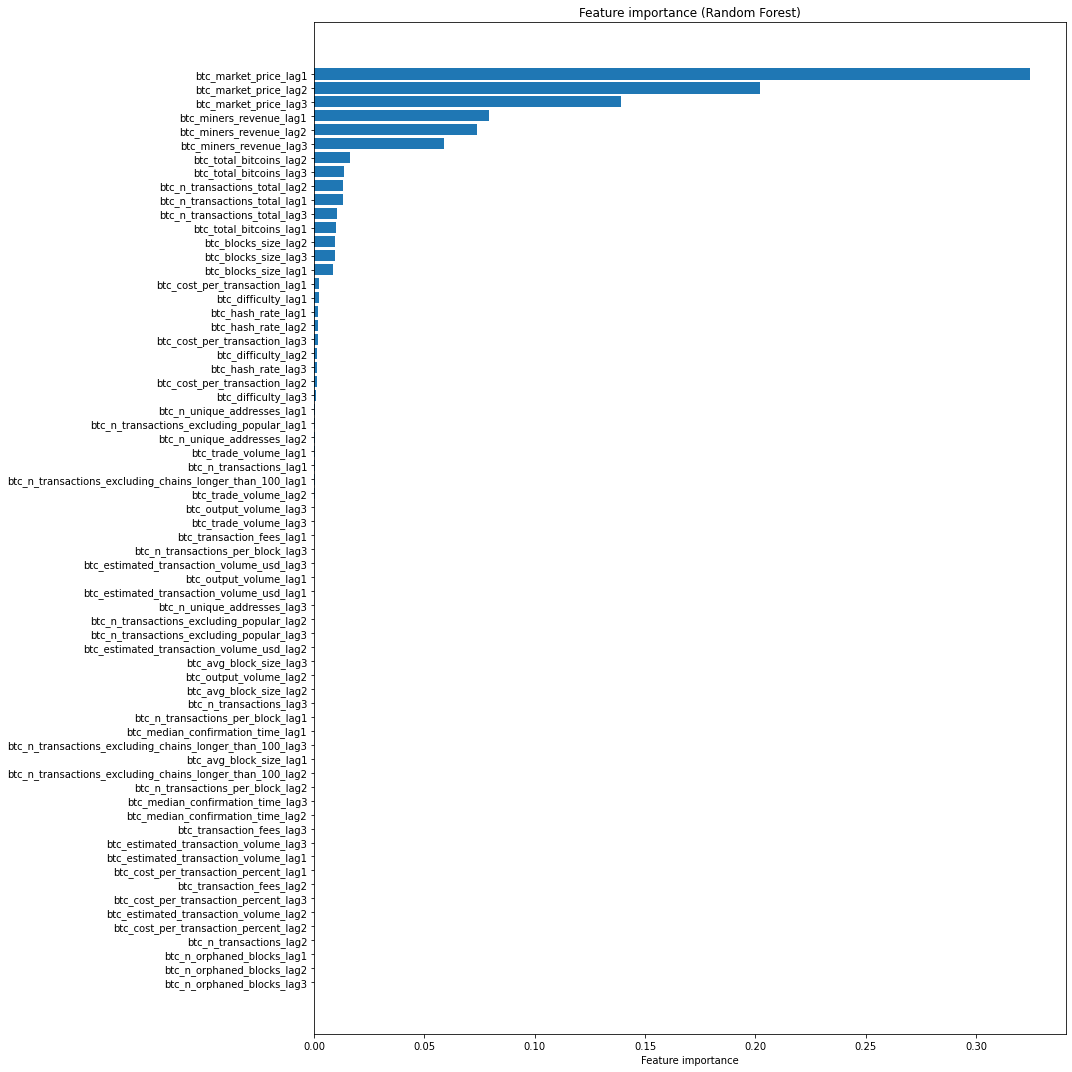

In [ ]:
indices = np.argsort(best_rf_model.feature_importances_)
plt.figure(figsize=(15,15))
plt.barh(X_train_tree.columns[indices], best_rf_model.feature_importances_[indices])
plt.title("Feature importance (Random Forest)")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()

## Gradient Boosting Machine

In [31]:
from sklearn.ensemble import GradientBoostingRegressor
gbm_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=5,
    random_state=598)
gbm_model.fit(X_train_tree,Y_train)

test_mse_gbm=[]
for Y_test_gbm_pred in gbm_model.staged_predict(X_test_tree):
    test_mse = mean_squared_error(Y_test,Y_test_gbm_pred)
    test_mse_gbm.append(test_mse)
print(f"Minimum TEST MSE of GBM with learning rate 0.01 is {min(test_mse_gbm)} at tree {np.argmin(test_mse_gbm)+1}")


Minimum TEST MSE of GBM with learning rate 0.01 is 28376334.09740152 at tree 477


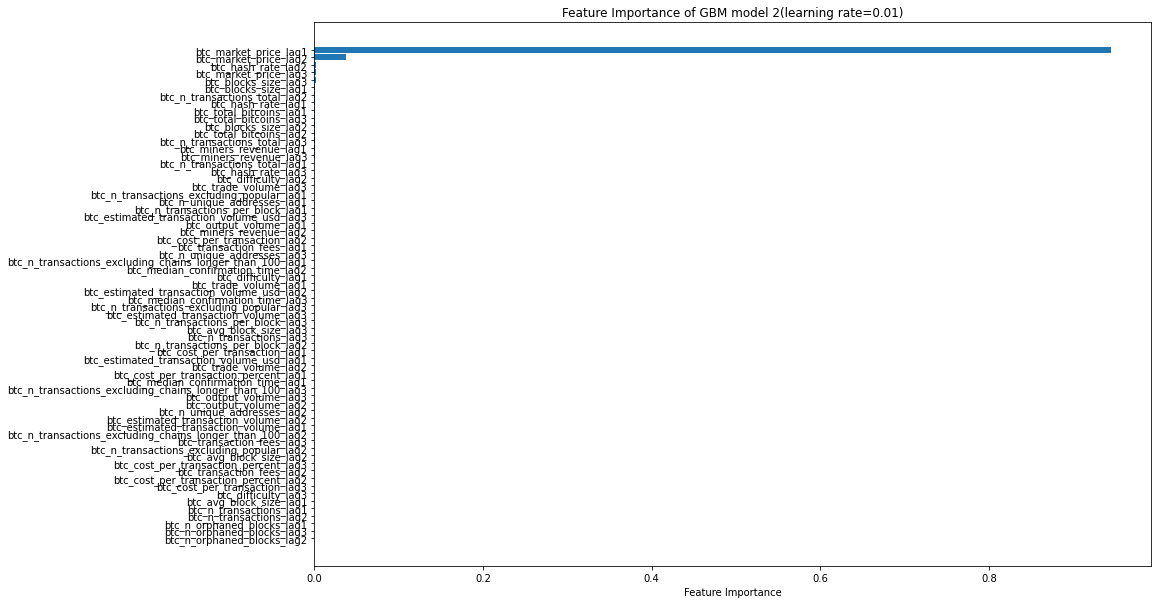

,feature,feature_importance
0,btc_market_price_lag1,0.944791
1,btc_market_price_lag2,0.038090
2,btc_hash_rate_lag2,0.002149
3,btc_market_price_lag3,0.002015
4,btc_blocks_size_lag3,0.001633
5,btc_blocks_size_lag1,0.001291
6,btc_n_transactions_total_lag2,0.001110
7,btc_hash_rate_lag1,0.001094
8,btc_total_bitcoins_lag1,0.000972
9,btc_total_bitcoins_lag3,0.000929


In [ ]:
feature_imp_soreted_idx = np.argsort(gbm_model.feature_importances_)
plt.figure(figsize=(15,10))
plt.title("Feature Importance of GBM model(learning rate=0.01)")
plt.xlabel("Feature Importance")
plt.barh(X_train_tree.columns[feature_imp_soreted_idx],gbm_model.feature_importances_[feature_imp_soreted_idx])
plt.show()
pd.DataFrame( 
            {'feature' : X_train_tree.columns[feature_imp_soreted_idx[::-1][:10]],
            'feature_importance' : gbm_model.feature_importances_[feature_imp_soreted_idx[::-1][:10]]
            }
            )

## Bitcoin Price Prediction – Model Comparison (Summary of all the models)

| Model                                | Train RMSE | Test RMSE | Train R² | Test R² | Key Observations |
|--------------------------------------|------------|-----------|----------|---------|------------------|
| **Full OLS Regression**              | ~14.5      | ~398      | 0.996    | 0.992   | High multicollinearity, unstable (large condition number), mostly insignificant predictors and not interpretable. |
| **Custom OLS (VIF < 5 & high corr.)**| –          | –         | Good Adj R² | -   | Still multicollinear, many predictors insignificant, not reliable for unseen data. |
| **Lasso Regression**                 | ~14        | ~392      | ~0.99    | ~0.99   | Best λ ≈ 0.24. Strong predictor = **btc_market_price_lag1**. Good prediction performance, but most of the predictors were not significant.Overfits: small train error, large test error. |
| **Ridge Regression**                 | ~15        | ~391      | ~0.996     | ~0.992    | Best λ ≈ 0.167. Good prediction performance. Overfits: small train error, large test error. Equal variance assumption violated. |
| **Ridge (Log-transformed Response)** | –          | Exploded  | –        | Poor    | Log transform didn’t work (price data not close to normal after log transformation). Ridge on raw price performed better. |
| **Splines + Ridge** (2–5 knots)      | ~14        | ~5200     | ~0.996   | Negative | Severe overfitting. Increasing knots didn’t help. Overfitting more than Ridge and Lasso. |
| **PCA + OLS (15 components)**        | ~35        | ~1993     | 0.979    | 0.795   | Reduced multicollinearity. Good Train R^2, decent Test R^2. But there is difference in train & test error→ not good generalization. Residuals fanned out. |

- Overall, from the above results we can see that **Ridge regression was a better model.** It had good prediction performance, with good Train and Test R^2. 
- But still the individual predictors were insignificant. This indicates multicollinearity.
- To get rid of multicollinearity, PCA was tried with 15 PCA components(choosen from the elbow plot above). Though the PCA results were not bad and reduced multicollinearity, the test predictions were not as good as ridge regression.
- **Hence so far the best model for predicting bitcoin price is ridge regression model**. 
- As an extension of this work, we can also try other tree based models, or Autoregressive Integrated Moving Average(ARIMA) model for forecasting time series data like Bitcoin prediction.

